In [1]:
%reset -f

import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import numpy as np

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
import insertHybrid
from networkx.drawing.nx_pydot import graphviz_layout


random.seed(42)
np.random.seed(42)

In [2]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 3)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5   #### hier kann die ANzahl der durchschnittlichen Kinder ausgewählt werden
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, dated_gene_tree)

# print(gene_colors)

# visualize(S, color_dict=species_colors)

# visualize(dated_gene_tree, color_dict=gene_colors)
# visualize(full_gene_tree, color_dict=gene_colors)
# visualize(pruned_gene_tree, color_dict=gene_colors)

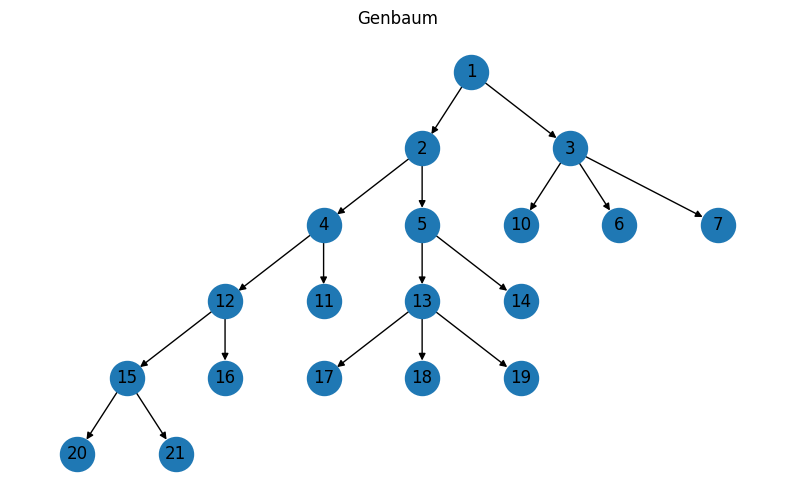

[(1, {'label': 1, 'event': 'S', 'reconc': 1, 'tstamp': 2.2614228023911034, 'transferred': 0, 'dist': 0.0}), (2, {'label': 2, 'event': 'D', 'reconc': (1, 2), 'tstamp': 1.7695155126923163, 'transferred': 0, 'dist': np.float64(0.6125018382434863), 'sibling_nr': 0}), (4, {'label': 4, 'event': 'S', 'reconc': 2, 'tstamp': 0.7563620869323426, 'transferred': 0, 'dist': np.float64(1.2615351483826558), 'sibling_nr': 0}), (12, {'label': 12, 'event': 'D', 'reconc': (2, 5), 'tstamp': 0.5544698511988531, 'transferred': 0, 'dist': np.float64(0.3194126086674895), 'sibling_nr': 0}), (15, {'label': 15, 'event': 'D', 'reconc': (2, 5), 'tstamp': 0.4322665621661629, 'transferred': 0, 'dist': np.float64(0.19333715928137596), 'sibling_nr': 0}), (20, {'label': 20, 'event': 'S', 'reconc': 5, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(1.0927235628748644), 'sibling_nr': 0}), (21, {'label': 21, 'event': 'S', 'reconc': 5, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(2.4521113268471417), 'sibling_nr

In [ ]:
N = insertHybrid.convert_to_nx(pruned_gene_tree)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

print(N.nodes(data = True))

Es wurde ein Hybrid zwischen node 13 und node 18 eingefügt und dieser wurde mit Node 14 verbunden
Es wurde ein Hybrid zwischen node 15 und node 21 eingefügt und dieser wurde mit Node 14 verbunden
Es wurde ein Hybrid zwischen node 13 und node 19 eingefügt und dieser wurde mit Node 6 verbunden


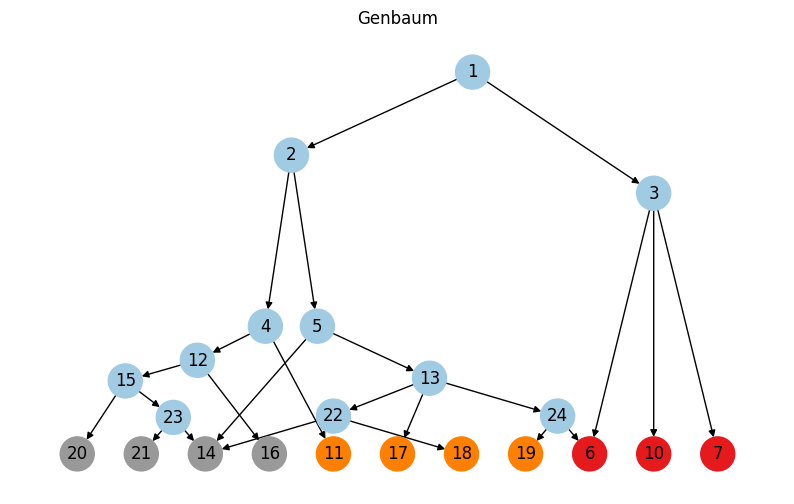

In [4]:
N = insertHybrid.insertHybrid(N,3)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

node_colors = insertHybrid.color_leaves(N)
# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_color=node_colors,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

# for node in G.nodes(data=True):
#     print(node)